# 5. Кластеризація k-Medians

k-Medians — варіант k-Means, що використовує **медіану** замість середнього для обчислення центрів кластерів та **Манхеттенську відстань** (L1) замість Евклідової (L2). Це робить алгоритм більш стійким до викидів.

In [1]:
import sys, os, json, time
sys.path.insert(0, os.path.abspath('.'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import *
from src.data_loader import create_scaled, subsample
from src.visualization import plot_cluster_scatter_2d, plot_silhouette_curve
from src.evaluation import compute_metrics, find_best_k, build_results_row, save_results
from src.clustering import run_kmedians, get_cluster_profiles

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv(PROCESSED_PATH)
with open(TOP_PAIRS_PATH) as f:
    pairs = json.load(f)

n_sample = SAMPLE_SIZES['kmedians']
df_sub = subsample(df, n_sample)
print(f"Повний датасет: {len(df)}, підвибірка: {len(df_sub)} записів")
print(f"Пари: {pairs}")

Повний датасет: 89741, підвибірка: 10000 записів
Пари: [['loudness', 'speechiness'], ['loudness', 'valence'], ['speechiness', 'valence'], ['energy', 'loudness']]


## 5.1 Підбір оптимального k

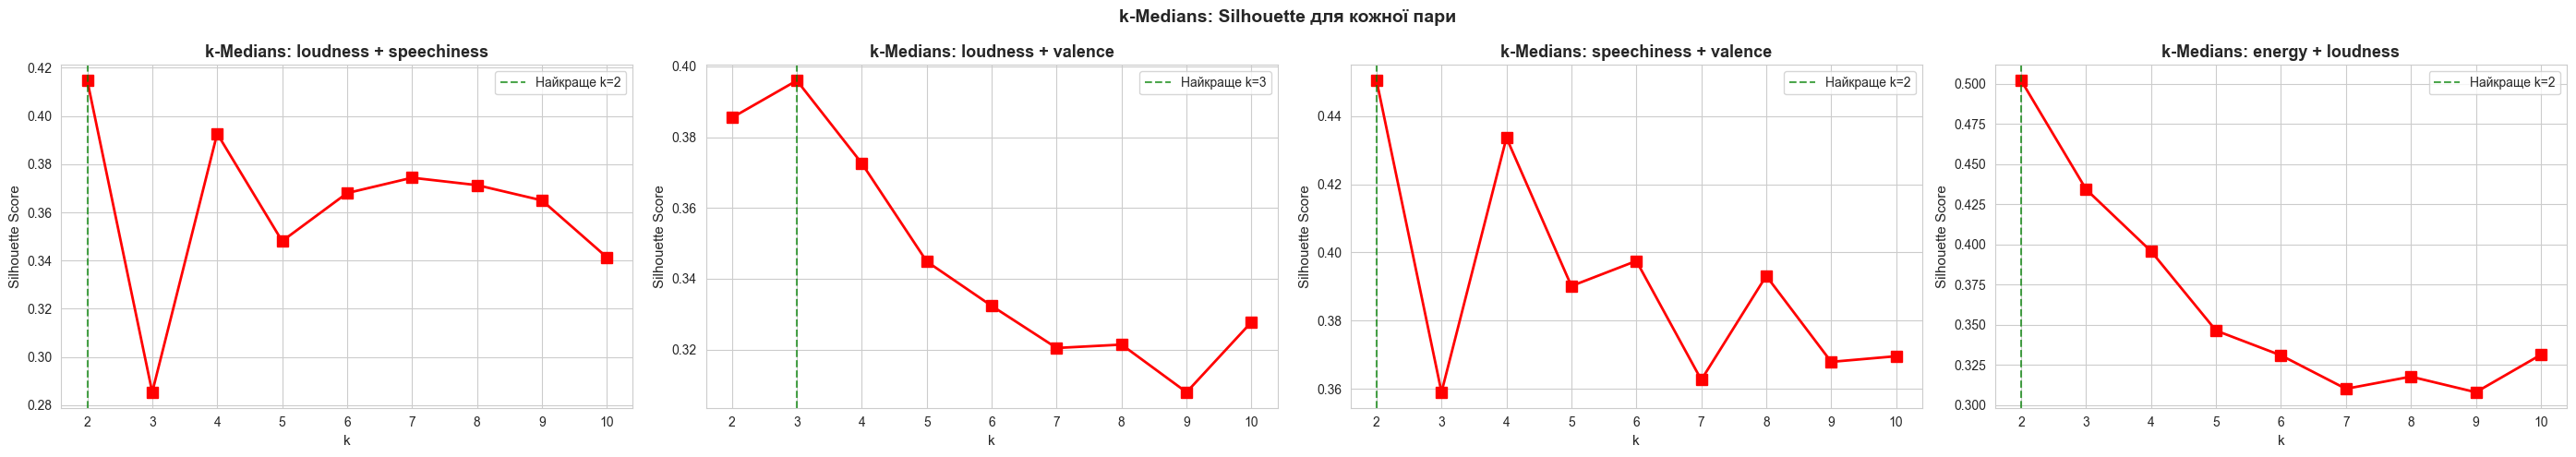

loudness + speechiness: найкращий k = 2
loudness + valence: найкращий k = 3
speechiness + valence: найкращий k = 2
energy + loudness: найкращий k = 2


In [3]:
best_k_pairs = {}
fig, axes = plt.subplots(1, len(pairs), figsize=(7 * len(pairs), 5))
if len(pairs) == 1:
    axes = [axes]

for i, pair in enumerate(pairs):
    X_pair, _ = create_scaled(df_sub, pair)
    X_arr = X_pair.values
    bk, scores = find_best_k(X_arr, K_RANGE,
                              lambda X, k: run_kmedians(X, k)[0])
    best_k_pairs[i] = bk
    plot_silhouette_curve(K_RANGE, scores,
                          f'k-Medians: {pair[0]} + {pair[1]}', ax=axes[i])

plt.suptitle('k-Medians: Silhouette для кожної пари', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

for i, pair in enumerate(pairs):
    print(f"{pair[0]} + {pair[1]}: найкращий k = {best_k_pairs[i]}")

## 5.2 Кластеризація пар та 2D-візуалізація

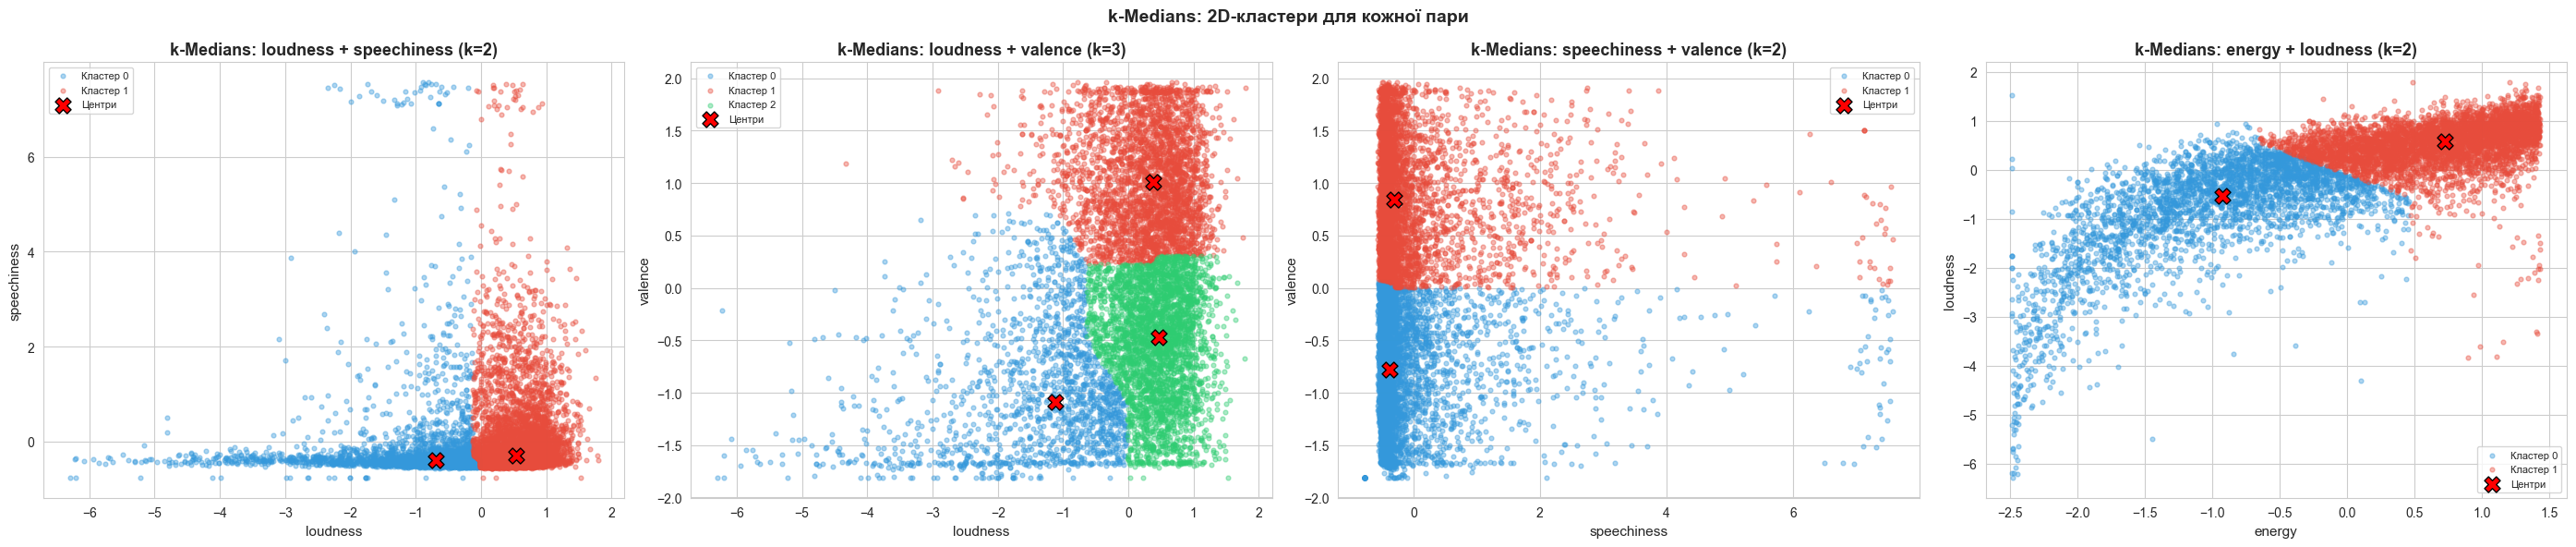

In [4]:
results = []
pair_labels = {}
fig, axes = plt.subplots(1, len(pairs), figsize=(7 * len(pairs), 6))
if len(pairs) == 1:
    axes = [axes]

for i, pair in enumerate(pairs):
    X_pair, _ = create_scaled(df_sub, pair)
    X_arr = X_pair.values
    best_k, _ = find_best_k(X_arr, K_RANGE,
                             lambda X, k: run_kmedians(X, k)[0])

    start = time.time()

    labels, medians = run_kmedians(X_arr, best_k)
    pair_labels[i] = labels
    elapsed = time.time() - start

    metrics = compute_metrics(X_arr, labels)
    results.append(build_results_row('k-Medians',
                                     f'{pair[0]} + {pair[1]}',
                                     best_k, metrics, elapsed))

    plot_cluster_scatter_2d(X_arr, labels, pair,
                            f'k-Medians: {pair[0]} + {pair[1]} (k={best_k})',
                            centers=medians, ax=axes[i])

plt.suptitle('k-Medians: 2D-кластери для кожної пари', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5.3 Жанровий склад кластерiв

Аналiз розподiлу музичних жанрiв мiж кластерами для кожної пари ознак.

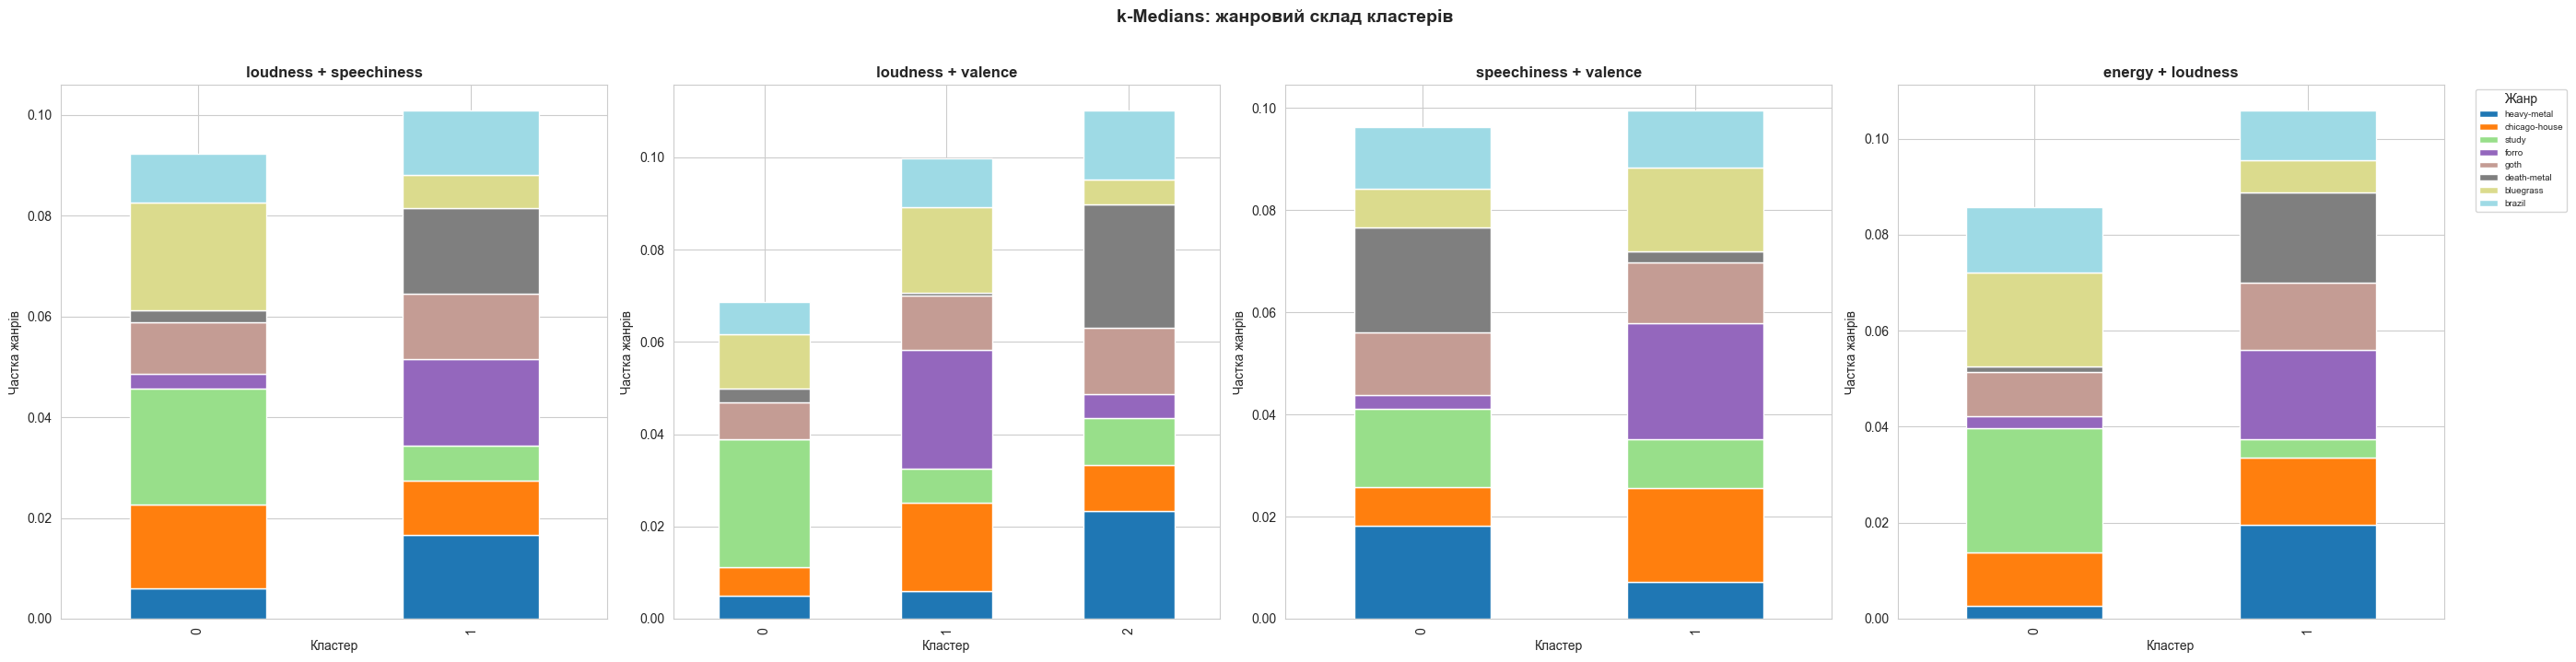

In [5]:
fig, axes = plt.subplots(1, len(pairs), figsize=(7 * len(pairs), 7))
if len(pairs) == 1:
    axes = [axes]

for i, pair in enumerate(pairs):
    df_temp = df_sub.copy()
    df_temp['cluster'] = pair_labels[i]
    top_genres = df_sub[GENRE_COL].value_counts().head(8).index
    genre_ct = pd.crosstab(df_temp['cluster'], df_temp[GENRE_COL], normalize='index')
    cols = [c for c in top_genres if c in genre_ct.columns]
    genre_ct[cols].plot(kind='bar', stacked=True, ax=axes[i], colormap='tab20', legend=False)
    axes[i].set_title(f'{pair[0]} + {pair[1]}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Кластер')
    axes[i].set_ylabel('Частка жанрiв')

axes[-1].legend(title='Жанр', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.suptitle('k-Medians: жанровий склад кластерiв', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [6]:
save_results(results, 'results_kmedians.csv')
pd.DataFrame(results)

Результати збережено: F:\University\Магістр\Data Mining\Lab2-Data-Mining-2026\results\results_kmedians.csv


,algorithm,pair,k,silhouette,davies_bouldin,time_sec
0,k-Medians,loudness + speechiness,2,0.414688,1.090011,0.0246
1,k-Medians,loudness + valence,3,0.395990,0.865811,0.0379
2,k-Medians,speechiness + valence,2,0.450399,0.939017,0.0170
3,k-Medians,energy + loudness,2,0.502085,0.750371,0.0132


## Пiдсумок

**k-Medians** використовує медiану як центр кластера та Манхеттенську вiдстань, що робить його бiльш стiйким до викидiв порiвняно з k-Means.

**Ключовi спостереження:**
- Алгоритм обирає центри, якi менш чутливi до екстремальних значень.
- Порiвняно з k-Means, k-Medians може давати дещо iнший розподiл кластерiв, особливо коли є сильнi викиди.
- Silhouette-оцiнки порiвняннi з k-Means, але рiзниця залежить вiд конкретної пари ознак.

Результати збережено у `results/results_kmedians.csv` для подальшого порiвняльного аналiзу.